<a href="https://colab.research.google.com/github/sgkang/geol_4330_canada_wide_gravity/blob/main/fwd_gravity_anomaly_2d.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install SimPEG choclo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.1/495.1 kB 6.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 221.0/221.0 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 13.7 MB/s eta 0:00:00
  Created wheel for SimPEG: filename=simpeg-0.23.0-py3-none-any.whl size=572311 sha256=6b3308438c90657abf13f1385feebbc62384246a530774d166462b6c71841a01
  Stored in directory: /root/.cache/pip/wheels/e3/0a/2e/94a1895a71964b1c21948ec0f640374242c24a9a3073346172
  Created wheel for pymatsolver: filename=pymatsolver-0.3.1-py3-none-any

In [ ]:
# SimPEG functionality
from simpeg.potential_fields import gravity
from simpeg.utils import model_builder
from simpeg import maps

# discretize functionality
from discretize import TensorMesh
from discretize.utils import mkvc, active_from_xyz

# Common Python functionality
import numpy as np
# from scipy.interpolate import LinearNDInterpolator
import matplotlib as mpl

mpl.rcParams.update({"font.size": 14})
import matplotlib.pyplot as plt

# Start with an analytic response

$$ g(x) = 2G\triangle \rho t \Big[\frac{\pi}{2} + tan^{-1}(\frac{x-x_c}{z})\Big]$$

In [ ]:
def get_gravity_reponse_for_semi_horizontal_slab(x, xc, z, drho, t, G=6.67430*1e-11):
  return 2*G*drho*t*(np.pi/2 + np.arctan((x-xc)/z)) * 1e5

In [ ]:
x = np.linspace(-1.5e5, 1.5e5, 101)
xc = 0.
drho = -1640
t = 5e3
z = 5e3
resp_1 = get_gravity_reponse_for_semi_horizontal_slab(x, xc, z, drho, t)
xc = 0.
drho = 430
t = 18.84*1e3
z = 13*1e3
resp_2 = get_gravity_reponse_for_semi_horizontal_slab(x, xc, z, drho, t)

Text(0, 0.5, 'Gravity Anomaly (mGal)')

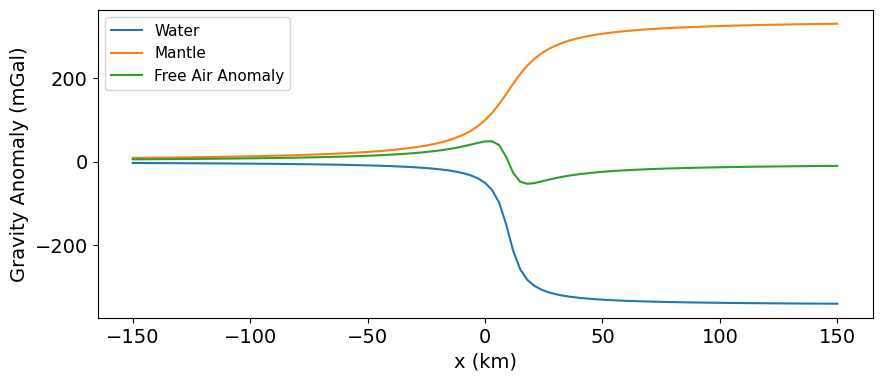

In [ ]:
fig = plt.figure(figsize=(10, 4))
plt.plot(x/1e3, resp_1, label='Water')
plt.plot(x/1e3, resp_2, label='Mantle')
plt.plot(x/1e3, resp_1+resp_2, label='Free Air Anomaly')
plt.legend(fontsize=11)
plt.xlabel('x (km)')
plt.ylabel('Gravity Anomaly (mGal)')

## Define the Survey

Surveys within SimPEG generally require the user to create and connect three types of objects:

- [receivers](xref:simpeg#simpeg.potential_fields.gravity.receivers.Point): which define the locations of field measurements and type of data being measured.
- [sources](xref:simpeg#simpeg.potential_fields.gravity.sources.SourceField): the passive or active sources responsible for generating geophysical responses, and their associated receivers.
- [survey](xref:simpeg#simpeg.potential_fields.gravity.survey.Survey): the object which stores and organizes all of the sources and receivers.

Here, we define the survey that will be used for the forward simulation. Gravity
surveys are simple to create. The user only needs an (N, 3) [numpy.ndarray](xref:numpy#numpy.ndarray) to define
the xyz locations of the observation locations, and a list of field components
which are to be measured. For the tutorial simulation, the receivers are located 5 m
above the surface topography and spaced 10 m apart.

In [ ]:
# Define the observation locations as an (N, 3) numpy array or load them from a file.
x = np.linspace(-1.5e5, 1.5e5, 101)
y = np.zeros_like(x)
z = np.zeros_like(x)
# z[x>0.] = -5e3
receiver_locations = np.c_[x, y, z]

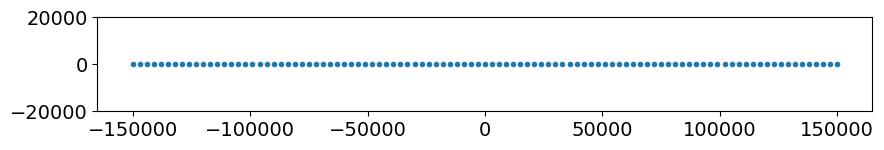

In [ ]:
fig = plt.figure(figsize=(10, 4))
plt.plot(receiver_locations[:,0], receiver_locations[:,1], '.')
plt.ylim(-2e4, 2e4)
plt.gca().set_aspect(1)

In [ ]:
# Define the component(s) of the field we want to simulate as strings within
# a list. Here we simulate only the vertical component of the gravity anomaly.
components = ["gz"]

# Use the observation locations and components to define receivers for the entire survey
# in one step. The set of receivers, even if it's only 1, are organized within a list.
receiver_list = gravity.receivers.Point(receiver_locations, components=components)
receiver_list = [receiver_list]

# Defining the source. For gravity surveys, we simply need to specific the list of
# receivers associated with the source field.
source_field = gravity.sources.SourceField(receiver_list=receiver_list)

# Defining the survey.
survey = gravity.survey.Survey(source_field)

If desired, we can extract various objects and properties from the objects used to generate the survey. E.g.

In [ ]:
print("# of data: {}".format(survey.nD))  # number of data that will be simulated
print(survey.source_field)  # the source field object
print(survey.source_field.receiver_list[0])  # the receiver object
print(receiver_list[0].locations[:5, :])  # the first 5 receiver locations

# of data: 101
[[-150000.       0.       0.]
 [-147000.       0.       0.]
 [-144000.       0.       0.]
 [-141000.       0.       0.]
 [-138000.       0.       0.]]


In [ ]:

survey.nD

101

## Design a (Tensor) Mesh

Meshes are designed using the [discretize](https://discretize.simpeg.xyz/en/main) package. See the [discretize user tutorials](https://discretize.simpeg.xyz/en/main/tutorials/mesh_generation/index.html) to learn more about creating meshes.
Here, the forward simulation is computed for a [tensor mesh](xref:discretize#discretize.TensorMesh). If you wanted to generate a [tree mesh](xref:discretize#discretize.TreeMesh) instead, you can use the code snippet from the [3D Forward Simulation of Gravity Gradiometry Data](fwd_gravity_gradiometry_3d.ipynb) tutorial.

The integral formulation for gravity essentially sums the independent gravity anomaly contribution for every voxel cell in the mesh. Since the kernel function that computes the contribution for a single cell is an analytic solution, small cells are not required to accurately compute the contributions from coarse structures with constant density (e.g. a rectangular prism). For complex structures however, or to define surface topography more accurately, finer cells may be needed. Furthermore, cells do not need to be cubic.

Here, a core cell width of 5 m is used within our survey region. Padding is used to extend the mesh outside the immediate survey area. The mesh will be plotted after we define our density contrast model.

In [ ]:
# Generate tensor mesh with top at z = 0 m
dh = 5 * 1e3
hx = [(1e10, 1), (dh, 60), (1e10, 1)]
hy = np.array([1e10])
hz = np.array([1e10, 18.84 * 1e3, 8*1e3, 5*1e3])
mesh = TensorMesh([hx, hy, hz], "CCN")

(-60000.0, 0.0)

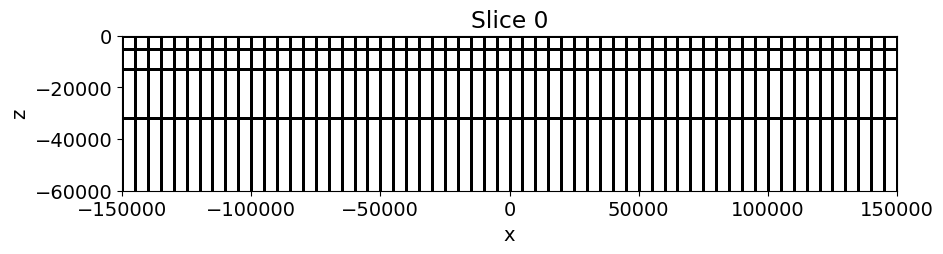

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(10, 4))
mesh.plot_slice(np.ones(mesh.nC)*np.nan, grid=True, normal='Y', ax=ax)
ax.set_aspect(1)
ax.set_xlim(-150e3, 150e3)
ax.set_ylim(-60e3, 0)

If desired, we can extract various properties of the mesh. E.g.

In [ ]:
print("# of cells: {}".format(mesh.n_cells))  # Number of cells
print("# of x-faces: {}".format(mesh.n_faces_x))  # Number of x-faces
print("Origin: {}".format(mesh.origin))  # bottom-southewest corner
print("Max cell volume: {}".format(mesh.cell_volumes.max()))  # Largest cell size
print(mesh.cell_centers[0:5, :])  # Cell center locations

# of cells: 248
# of x-faces: 252
Origin: [-1.00001500e+10 -5.00000000e+09 -1.00000318e+10]
Max cell volume: 1e+30
[[-5.00015000e+09  0.00000000e+00 -5.00003184e+09]
 [-1.47500000e+05  0.00000000e+00 -5.00003184e+09]
 [-1.42500000e+05  0.00000000e+00 -5.00003184e+09]
 [-1.37500000e+05  0.00000000e+00 -5.00003184e+09]
 [-1.32500000e+05  0.00000000e+00 -5.00003184e+09]]


## Define the Model

Here, we create the model that will be used to predict gravity anomaly data.
Recall that our model is the density constrast values for all active mesh cells.
So the model is a 1D [numpy.ndarray](xref:numpy#numpy.ndarray) whose length is
equal to the number of model parameters.
**In SimPEG, density contrast values are defined in units of g/cc**.
Here, the model consists of a less dense block and a more dense sphere.
We plot the model using the [plot_slice](xref:discretize#discretize.TensorMesh.plot_slice) method.

In [ ]:
# Define density contrast values for each unit in g/cc
d_water_density = -1.64
d_mantle_density = 0.43

In [ ]:
# Instantiate a vector array.
density = np.zeros(mesh.n_cells)

# You could find the indicies of specific cells within the model and change their
# values to add structures.
ind_mantle = (
    (mesh.cell_centers[:, 0] > 0.0)
    & (mesh.cell_centers[:, 2] < -13*1e3)
    & (mesh.cell_centers[:, 2] > -31.84*1e3)
)
ind_water = (
    (mesh.cell_centers[:, 0] > 0.0)
    & (mesh.cell_centers[:, 2] > -5*1e3)
)
density[ind_mantle] = d_mantle_density
density[ind_water] = d_water_density
density_mantle = np.zeros(mesh.n_cells)
density_mantle[ind_mantle] = d_mantle_density
density_water = np.zeros(mesh.n_cells)
density_water[ind_water] = d_water_density

In [ ]:
mesh.nodes_z

array([-1.00000318e+10, -3.18400000e+04, -1.30000000e+04, -5.00000000e+03,
        0.00000000e+00])

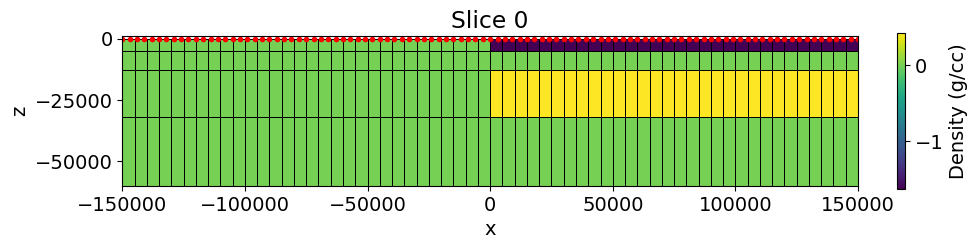

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(10, 4))
out = mesh.plot_slice(density, normal='Y', ax=ax, grid_opts={'color': 'k', 'lw':0.5})
plt.colorbar(out[0], ax=ax, label='Density (g/cc)', fraction=0.01)
ax.set_aspect(1)
ax.set_xlim(-150e3, 150e3)
ax.set_ylim(-60e3, 0)
ax.plot(receiver_locations[:,0], receiver_locations[:,2], 'r.')
ax.set_aspect(1)
ax.set_xlim(-150e3, 150e3)
ax.set_ylim(-60e3, 1e3)
plt.tight_layout()

## Define the Forward Simulation

In SimPEG, the physics of the forward simulation is defined by creating an instance of an appropriate simulation class.
In this case, we use the simulation class for the [3D integral formulation](xref:simpeg#simpeg.potential_fields.gravity.Simulation3DIntegral). To fully define the forward simulation, we need to connect the simulation object to:

- the survey
- the mesh
- the indices of the active cells
- the mapping from the model to the active cells

This is accomplished by setting each one of the aforementioned items as a property of the simulation object.
Additional keyword arguments can also be set which impact the forward simulation.
Because we are only simulating data for a single model, there is no benefit to storing the sensitivities for the forward simulation. As a result, we set the ``store_sensitivities`` property to *'forward_only'*.

In [ ]:
simulation = gravity.simulation.Simulation3DIntegral(
    survey=survey,
    mesh=mesh,
    rhoMap=maps.IdentityMap(mesh),
    # active_cells=active_cells,
    store_sensitivities="forward_only",
    engine="choclo",
)

:::{tip}
By choosing `engine="choclo"` we can make our simulation to run the faster and more memory efficient implementation of the gravity forward that uses [Numba](https://numba.pydata.org/) and [Choclo](https://www.fatiando.org/choclo) under the hood. To do so, we need to have [Choclo installed](https://www.fatiando.org/choclo/latest/install.html).
:::

## Simulate Gravity Anomaly Data

Once any simulation within SimPEG has been properly constructed, simulated data for a given model vector can be computed using the [dpred](xref:simpeg#simpeg.simulation.BaseSimulation.dpred) method. **SimPEG uses a right-handed coordinate system to simulate gravity anomaly data where Z is positive upward!!!** Please be aware of this when using gravity anomaly data to infer the locations of more and less dense structures. E.g. above a more dense block, a negative gravity anomaly is observed because gravity is stronger in the -ve Z direction. In SimPEG, gravity anomaly values are in **units mGal.**

In [ ]:
dpred = simulation.dpred(density)
dpred_mantle = simulation.dpred(density_mantle)
dpred_water = simulation.dpred(density_water)

In [ ]:
# mesh.n_cells

Text(0, 0.5, 'Gravity Anomaly (mGal)')

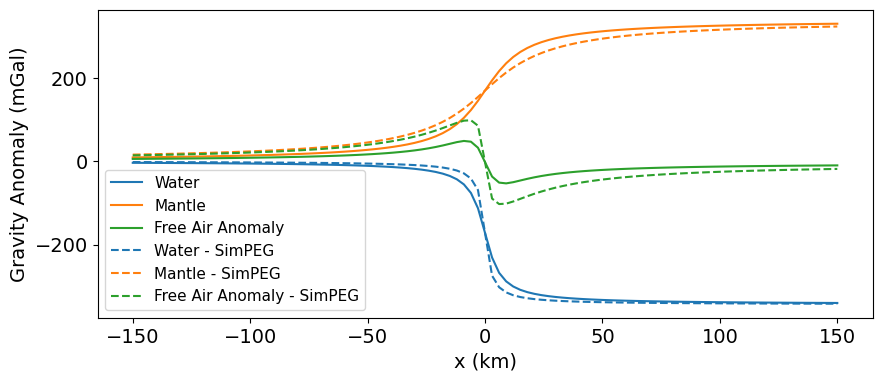

In [ ]:

fig = plt.figure(figsize=(10, 4))
plt.plot(x/1e3, resp_1, label='Water')
plt.plot(x/1e3, resp_2, label='Mantle')
plt.plot(x/1e3, resp_1+resp_2, label='Free Air Anomaly')
plt.plot(x/1e3,   -dpred_water, '--', label='Water - SimPEG', color='C0')
plt.plot(x/1e3, -dpred_mantle, '--', label='Mantle - SimPEG', color='C1')
plt.plot(x/1e3, -dpred, '--', label='Free Air Anomaly - SimPEG', color='C2')
plt.legend(fontsize=11)
plt.xlabel('x (km)')
plt.ylabel('Gravity Anomaly (mGal)')